# 7. Exporting Results

Export DVH curves, a structure-level statistics table, and a rendered figure.


In [1]:
from pathlib import Path
from tempfile import mkdtemp

from dosemetrics.metrics import dvh
from dosemetrics.utils import (
    dose_statistics_table,
    load_example_study,
    plot_subject_dvhs,
    save_figure,
)

dose, structures = load_example_study("longitudinal/time_point_1")
output_dir = Path(mkdtemp(prefix="dosemetrics_export_"))


## Export tables


In [2]:
dvh_table = dvh.create_dvh_table(dose, structures, step_size=0.1)
statistics_table = dose_statistics_table(dose, structures)

dvh_table.to_csv(output_dir / "dvh_curves.csv", index=False, float_format="%.3f")
statistics_table.to_csv(output_dir / "dose_statistics.csv", float_format="%.3f")
statistics_table.head(8).round(2)


,Volume (cc),Mean dose (Gy),Minimum dose (Gy),Maximum dose (Gy),D98 (Gy),D95 (Gy),D50 (Gy),D02 (Gy)
Structure,,,,,,,,
Pituitary,0.85,33.12,27.26,49.97,27.36,27.79,32.11,43.29
OpticNerve_L,0.50,40.71,22.03,58.41,23.03,25.09,39.55,58.29
Cochlea_R,0.10,2.72,2.22,3.24,2.23,2.25,2.73,3.21
CTV,291.48,60.48,50.68,65.71,57.89,58.47,60.50,62.89
OpticNerve_R,0.66,16.82,10.63,36.04,11.24,11.36,14.61,33.99
Cochlea_L,0.07,5.98,4.39,7.40,4.41,4.44,6.95,7.35
PTV,368.46,60.15,48.60,65.71,56.57,57.66,60.25,62.81
LacrimalGland_L,0.90,22.81,9.21,41.75,9.89,12.39,22.56,38.57


## Export a figure


Saved: /tmp/dosemetrics-test-tmp/dosemetrics_export_mk_w6gyn/dvh.png
Saved: /tmp/dosemetrics-test-tmp/dosemetrics_export_mk_w6gyn/dvh.svg


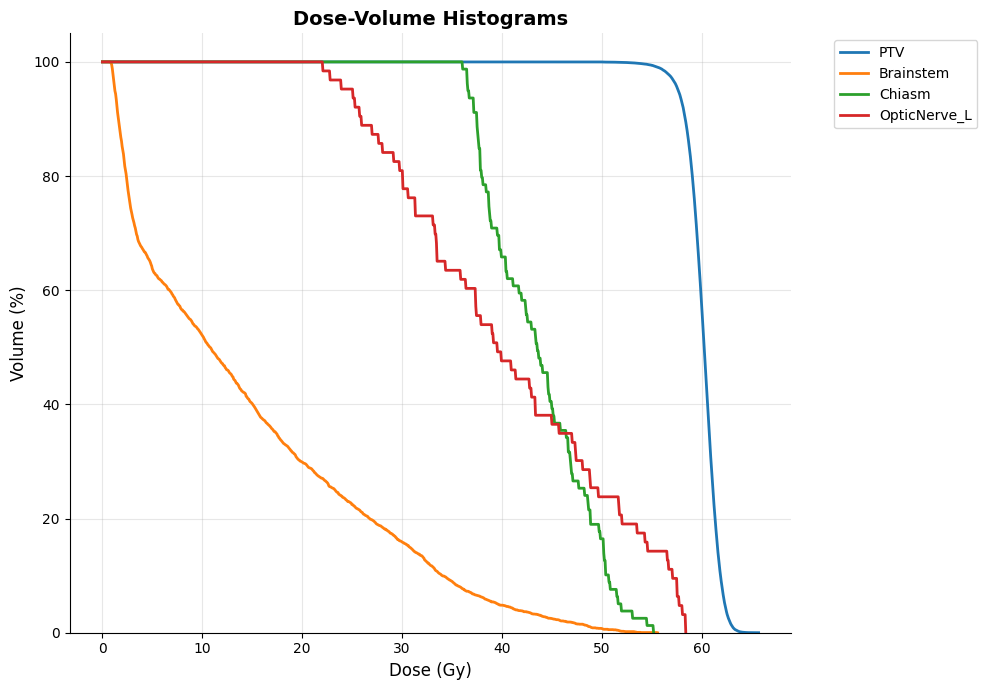

In [3]:
fig, ax = plot_subject_dvhs(
    dose,
    structures,
    ["PTV", "Brainstem", "Chiasm", "OpticNerve_L"],
    color_by_type=False,
)
save_figure(fig, output_dir / "dvh", formats=["png", "svg"])


## Created files


In [4]:
for path in sorted(output_dir.iterdir()):
    print(f"{path.name:24s} {path.stat().st_size / 1024:8.1f} KB")


dose_statistics.csv           1.0 KB
dvh.png                     204.1 KB
dvh.svg                      56.4 KB
dvh_curves.csv              145.7 KB
